#  Hospital Readmission Risk Prediction Using Machine Learning

This notebook builds an end-to-end machine learning workflow on the **Diabetes 130-US hospitals dataset** to predict whether a patient will be **readmitted within 30 days**.

## Project objective
Hospital readmissions are expensive and often used as a signal of care quality, discharge effectiveness, and post-discharge support. The goal of this project is to predict **30-day readmission risk** so that high-risk patients can be prioritised for follow-up and intervention.

## What this notebook covers
- Data loading and inspection
- Data cleaning and target definition
- Exploratory analysis
- Baseline and advanced modelling
- Class imbalance handling
- Threshold tuning
- Feature importance
- Business interpretation

## Why this dataset is strong
This is a real healthcare dataset with over **100,000** encounters across **130 hospitals**. Unlike toy datasets, it contains:
- mixed numeric and categorical variables
- missing values and noisy categories
- real readmission outcomes
- a realistic imbalanced target

That makes it a good case study for healthcare analytics, machine learning, and interview discussions.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

## 1. Load the dataset

In [2]:
df = pd.read_csv("diabetic_data.csv")
print("IDS_mapping.csv", df.shape)
df.head()

IDS_mapping.csv (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Initial inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [4]:
df.isna().sum().sort_values(ascending=False).head(15)

encounter_id      0
troglitazone      0
chlorpropamide    0
glimepiride       0
acetohexamide     0
glipizide         0
glyburide         0
tolbutamide       0
pioglitazone      0
rosiglitazone     0
acarbose          0
miglitol          0
tolazamide        0
patient_nbr       0
examide           0
dtype: int64

The raw file uses `?` in several categorical columns to represent missing values, so we convert those first.

In [5]:
df = df.replace("?", np.nan)

missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df) * 100).round(2)
missing_summary.head(15)

,missing_count,missing_pct
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02
encounter_id,0,0.00
tolazamide,0,0.00
glyburide,0,0.00


## 3. Define the prediction target

The original `readmitted` column has three classes:
- `<30` = readmitted within 30 days
- `>30` = readmitted after 30 days
- `NO` = no readmission

For this project:

- **1** = readmitted within 30 days
- **0** = all other cases

In [6]:
df["target_30d_readmit"] = (df["readmitted"] == "<30").astype(int)

target_dist = df["target_30d_readmit"].value_counts().rename_axis("class").to_frame("count")
target_dist["pct"] = (target_dist["count"] / len(df) * 100).round(2)
target_dist

,count,pct
class,,
0,90409,88.84
1,11357,11.16


This target is imbalanced, which is normal in healthcare prediction problems. Because of that, **ROC-AUC**, **PR-AUC**, and **recall** are more informative than accuracy alone.

## 4. Drop identifiers and very sparse fields

In [7]:
drop_cols = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "weight",
    "payer_code",
    "medical_specialty"
]

df_model = df.drop(columns=drop_cols)

print("Remaining shape:", df_model.shape)
df_model.head()

Remaining shape: (101766, 45)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target_30d_readmit
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0


Why these columns were removed:
- `encounter_id`, `patient_nbr`: identifiers, not useful predictive signals
- `readmitted`: original label, replaced by the binary target
- `weight`, `payer_code`, `medical_specialty`: large amounts of missing data

## 5. Feature types

In [8]:
X = df_model.drop(columns=["target_30d_readmit"])
y = df_model["target_30d_readmit"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))
print("\nSample categorical columns:", categorical_cols[:10])
print("\nNumeric columns:", numeric_cols)

Categorical columns: 33
Numeric columns: 11

Sample categorical columns: ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide']

Numeric columns: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


## 6. Quick exploratory analysis

In [9]:
numeric_summary = df_model[numeric_cols + ["target_30d_readmit"]].groupby("target_30d_readmit").mean().T
numeric_summary.sort_values(by=1, ascending=False).head(15)

target_30d_readmit,0,1
num_lab_procedures,42.953644,44.226028
num_medications,15.911137,16.903143
number_diagnoses,7.388667,7.692789
admission_source_id,5.746054,5.821168
time_in_hospital,4.349224,4.768249
discharge_disposition_id,3.621022,4.468874
admission_type_id,2.029975,1.976490
num_procedures,1.347123,1.280884
number_inpatient,0.561648,1.224003
number_outpatient,0.360871,0.436911


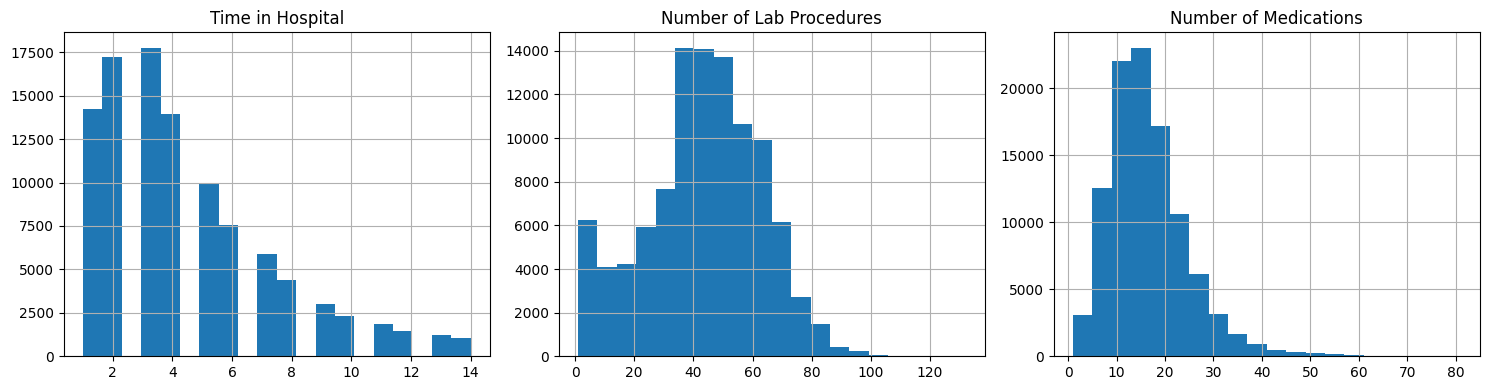

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_model["time_in_hospital"].hist(ax=axes[0], bins=20)
axes[0].set_title("Time in Hospital")

df_model["num_lab_procedures"].hist(ax=axes[1], bins=20)
axes[1].set_title("Number of Lab Procedures")

df_model["num_medications"].hist(ax=axes[2], bins=20)
axes[2].set_title("Number of Medications")

plt.tight_layout()
plt.show()

In [11]:
top_age = (
    pd.crosstab(df_model["age"], df_model["target_30d_readmit"], normalize="index") * 100
).round(2)
top_age

target_30d_readmit,0,1
age,,
[0-10),98.14,1.86
[10-20),94.21,5.79
[20-30),85.76,14.24
[30-40),88.77,11.23
[40-50),89.40,10.60
[50-60),90.33,9.67
[60-70),88.87,11.13
[70-80),88.23,11.77
[80-90),87.92,12.08


## 7. Train/test split
We use a stratified split so the target distribution stays consistent in both training and test sets.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target rate:", round(y_train.mean(), 4))
print("Test target rate:", round(y_test.mean(), 4))

Train shape: (81412, 44)
Test shape: (20354, 44)

Train target rate: 0.1116
Test target rate: 0.1116


## 8. Build preprocessing pipelines

We have a mix of:
- numeric variables
- categorical variables
- missing values

So we use:
- median imputation for numeric fields
- most frequent imputation for categoricals
- one-hot encoding for categoricals
- scaling for Logistic Regression

In [13]:
numeric_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01))
])

preprocessor_lr = ColumnTransformer(transformers=[
    ("num", numeric_transformer_lr, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

preprocessor_rf = ColumnTransformer(transformers=[
    ("num", numeric_transformer_rf, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## 9. Create models

We compare:
1. **Logistic Regression** as a strong baseline
2. **Random Forest** as a more flexible non-linear model

Both use class balancing because the positive class is smaller.

In [14]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("model", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="liblinear"
    ))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestClassifier(
        n_estimators=250,
        max_depth=12,
        min_samples_split=20,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

## 10. Train the models

In [15]:
log_reg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


## 11. Evaluation helper

In [16]:
def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    print("=" * 70)
    print(f"{model_name} | threshold = {threshold:.2f}")
    print("=" * 70)
    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"PR-AUC  : {pr_auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return y_proba, y_pred, roc_auc, pr_auc, cm

## 12. Evaluate at the default 0.50 threshold

In [17]:
log_proba, log_pred, log_roc, log_pr, log_cm = evaluate_model(
    log_reg_pipeline, X_test, y_test, "Logistic Regression", threshold=0.50
)

rf_proba, rf_pred, rf_roc, rf_pr, rf_cm = evaluate_model(
    rf_pipeline, X_test, y_test, "Random Forest", threshold=0.50
)

Logistic Regression | threshold = 0.50
ROC-AUC : 0.6532
PR-AUC  : 0.2032

Confusion Matrix:
[[12029  6054]
 [ 1032  1239]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.67      0.77     18083
           1       0.17      0.55      0.26      2271

    accuracy                           0.65     20354
   macro avg       0.55      0.61      0.52     20354
weighted avg       0.84      0.65      0.72     20354

Random Forest | threshold = 0.50
ROC-AUC : 0.6684
PR-AUC  : 0.2122

Confusion Matrix:
[[12598  5485]
 [ 1034  1237]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79     18083
           1       0.18      0.54      0.28      2271

    accuracy                           0.68     20354
   macro avg       0.55      0.62      0.53     20354
weighted avg       0.84      0.68      0.74     20354



At the default threshold, Random Forest often performs better overall, but threshold selection depends on the business goal.

In readmission work, recall is often important because **missing a high-risk patient can be costly**.

## 13. Threshold tuning for better recall

In [18]:
precision, recall, thresholds = precision_recall_curve(y_test, rf_proba)

threshold_table = pd.DataFrame({
    "threshold": np.append(thresholds, 1.0),
    "precision": precision,
    "recall": recall
})

threshold_table.head(15)

,threshold,precision,recall
0,0.188638,0.111575,1.0
1,0.200672,0.111581,1.0
2,0.201997,0.111586,1.0
3,0.209419,0.111592,1.0
4,0.212139,0.111597,1.0
5,0.215110,0.111603,1.0
6,0.215587,0.111608,1.0
7,0.220246,0.111614,1.0
8,0.220560,0.111619,1.0
9,0.220646,0.111624,1.0


In [19]:
chosen_threshold = 0.30

rf_proba_tuned, rf_pred_tuned, rf_roc_tuned, rf_pr_tuned, rf_cm_tuned = evaluate_model(
    rf_pipeline, X_test, y_test, "Random Forest (Recall-Optimised)", threshold=chosen_threshold
)

Random Forest (Recall-Optimised) | threshold = 0.30
ROC-AUC : 0.6684
PR-AUC  : 0.2122

Confusion Matrix:
[[  481 17602]
 [   11  2260]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.03      0.05     18083
           1       0.11      1.00      0.20      2271

    accuracy                           0.13     20354
   macro avg       0.55      0.51      0.13     20354
weighted avg       0.88      0.13      0.07     20354



Lowering the threshold typically:
- increases recall
- catches more high-risk patients
- increases false positives

That trade-off is often acceptable in healthcare screening and triage settings.

## 14. ROC curve

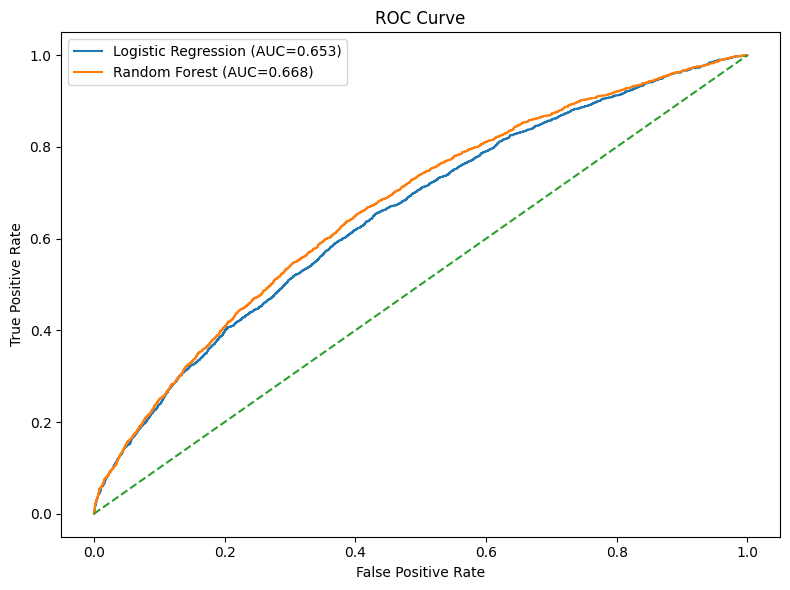

In [20]:
log_fpr, log_tpr, _ = roc_curve(y_test, log_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(8, 6))
plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC={log_roc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_roc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 15. Feature importance from Random Forest

In [21]:
ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_names = ohe.get_feature_names_out(categorical_cols)

all_feature_names = numeric_cols + list(encoded_cat_names)

feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_pipeline.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
9,number_inpatient,0.217571
1,discharge_disposition_id,0.088699
6,num_medications,0.050003
4,num_lab_procedures,0.048182
3,time_in_hospital,0.045046
8,number_emergency,0.043582
10,number_diagnoses,0.037507
5,num_procedures,0.021584
7,number_outpatient,0.018637
0,admission_type_id,0.017006


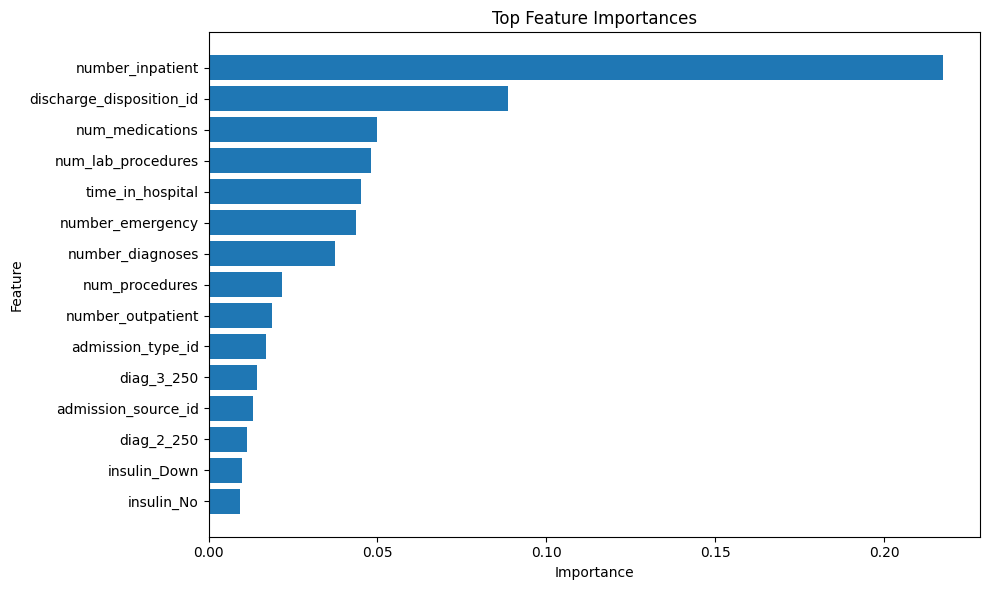

In [22]:
top_n = 15
plot_data = feature_importance.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["feature"], plot_data["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()

## 16. Save scored predictions
This creates a file you can use for further analysis or reporting.

In [23]:
results = X_test.copy()
results["actual_readmitted_30d"] = y_test.values
results["rf_probability"] = rf_proba
results["rf_prediction_0_50"] = rf_pred
results["rf_prediction_0_30"] = rf_pred_tuned

results.to_csv("readmission_predictions_output.csv", index=False)
print("Saved: readmission_predictions_output.csv")
results.head()

Saved: readmission_predictions_output.csv


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,actual_readmitted_30d,rf_probability,rf_prediction_0_50,rf_prediction_0_30
99195,Caucasian,Female,[80-90),1,1,7,4,40,0,17,0,0,1,584,276,276,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,0.525782,1,1
63319,AfricanAmerican,Male,[60-70),1,1,7,5,29,3,22,0,0,0,786,427,401,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,0,0.365608,0,1
64536,Caucasian,Female,[70-80),3,22,1,2,26,2,29,2,0,1,733,496,250,5,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,0.507063,1,1
13039,Caucasian,Male,[50-60),3,18,1,5,43,3,34,0,0,1,440,996,433,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,1,0.530783,1,1
37502,AfricanAmerican,Male,[70-80),6,22,17,12,77,6,38,0,0,0,47,493,263,9,None,None,No,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,1,0.521868,1,1


## 17. Project conclusion

This notebook built a real **30-day hospital readmission prediction** workflow using a large hospital dataset. Two models were trained and compared:

- **Logistic Regression** provided an interpretable baseline
- **Random Forest** captured more complex relationships and offered stronger predictive performance

The project also showed why **threshold tuning** matters in healthcare. A lower threshold can improve recall and help identify more patients who need intervention, even if that means more false positives.

## Business value
A model like this can support:
- discharge planning
- targeted patient outreach
- case management prioritisation
- post-discharge monitoring
- reduction in avoidable readmissions

## Limitations
- This is a retrospective public dataset, not a live hospital deployment
- No temporal validation was performed
- No external validation dataset was used
- Model fairness and calibration should be checked before real-world use

## Next improvements
- add XGBoost or LightGBM
- perform hyperparameter tuning
- test calibration
- map coded hospital fields using `IDS_mapping 2.csv`
- build a dashboard for risk monitoring

## Interview-ready summary

> I built a machine learning pipeline on the UCI Diabetes 130-US hospitals dataset to predict 30-day hospital readmission risk. I cleaned missing values, transformed high-cardinality categorical variables with one-hot encoding, handled class imbalance, compared Logistic Regression and Random Forest models, and tuned the decision threshold to improve recall. I evaluated the models with ROC-AUC and PR-AUC and used feature importance to explain the main drivers of readmission risk. The project was designed to reflect a realistic healthcare analytics workflow rather than a toy classification task.